# Bike Lane Quality Classification — Group Pipeline (Unsupervised + Supervised + Deployment)

**Course:** 5ARE0 — Human Activity Recognition Assignment
**Pipeline:** multi-participant merge → preprocessing → feature engineering/selection → 4 unsupervised models → 4 supervised models (leave-one-participant-out) → model comparison → deployment (smooth/bumpy classification of a new recording)

This notebook merges all 6 recordings (Himanshu, Aniket, Yuhan — each with one smooth and
one bumpy ride), builds a shared feature set, and applies four unsupervised clustering
methods to see whether smooth/bumpy structure emerges without using the labels for training.
Labels are used **only afterward**, to evaluate whether each method's discovered clusters
line up with the true classes.

**Data-quality history (worth a paragraph in the report):** the first round of smooth
recordings for Himanshu and Aniket turned out to include lane imperfections (their "smooth"
rides looked almost as rough as bumpy ones — 23% and 82% of the ride above an activity
threshold, vs. ~1-2% for genuinely smooth rides), so both were re-recorded on cleaner
stretches. Results below use the re-recorded data.

> **Group members:** add names and student numbers here (required on the title page).


## 0. Environment & Reproducibility

In [1]:
import sys, platform
import pandas as pd, numpy as np, sklearn, matplotlib
print("Python version:", sys.version)
print("Platform:", platform.platform())
print("pandas:", pd.__version__, "| numpy:", np.__version__,
      "| scikit-learn:", sklearn.__version__, "| matplotlib:", matplotlib.__version__)


Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
pandas: 2.2.3 | numpy: 2.3.5 | scikit-learn: 1.9.0 | matplotlib: 3.10.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score

pd.set_option('display.max_columns', None)


## 1. Data Loading & Sensor Merge (All Participants)

Same merge logic as before: `Accelerometer`, `Gravity`, and `Gyroscope` share identical
timestamps row-for-row (confirmed per recording via the assertions below), so a direct
column-wise merge is safe without interpolation.

**Edit the `RECORDINGS` list below** to point at your local folders — one entry per
(participant, condition) recording. This is the only thing that needs to change as more
data comes in.

In [3]:
def load_and_merge(acc_path, grav_path, gyro_path):
    """Merge Accelerometer, Gravity, and Gyroscope CSVs (same clock, same row count)
    into a single per-timestamp dataframe."""
    acc  = pd.read_csv(acc_path).rename(columns={'x': 'acc_x',  'y': 'acc_y',  'z': 'acc_z'})
    grav = pd.read_csv(grav_path).rename(columns={'x': 'grav_x', 'y': 'grav_y', 'z': 'grav_z'})
    gyro = pd.read_csv(gyro_path).rename(columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'})

    assert len(acc) == len(grav) == len(gyro), "Row counts differ — use merge_asof instead"
    assert (acc['time'].values == grav['time'].values).all(), "Timestamps misaligned (accel vs gravity)"
    assert (acc['time'].values == gyro['time'].values).all(), "Timestamps misaligned (accel vs gyro)"

    df = acc[['time', 'seconds_elapsed', 'acc_x', 'acc_y', 'acc_z']].copy()
    df[['grav_x', 'grav_y', 'grav_z']] = grav[['grav_x', 'grav_y', 'grav_z']]
    df[['gyro_x', 'gyro_y', 'gyro_z']] = gyro[['gyro_x', 'gyro_y', 'gyro_z']]
    return df


In [4]:
# --- EDIT THESE PATHS to point at your own exported recordings ---
# Smooth rides for Himanshu and Aniket are the RE-RECORDED versions (cleaner lanes).
RECORDINGS = [
    dict(folder='../data_raw/Smooth/Himanshu_Smooth_data', participant='Himanshu', label='smooth',
         acc='Accelerometer.csv', grav='Gravity.csv', gyro='Gyroscope.csv'),
    dict(folder='../data_raw/Bumpy/Himanshu_Bumpy_data', participant='Himanshu', label='bumpy',
         acc='Accelerometer.csv', grav='Gravity.csv', gyro='Gyroscope.csv'),
    dict(folder='../data_raw/Smooth/Aniket_Smooth_data', participant='Aniket', label='smooth',
         acc='Accelerometer.csv', grav='Gravity.csv', gyro='Gyroscope.csv'),
    dict(folder='../data_raw/Bumpy/Aniket_Bumpy_data', participant='Aniket', label='bumpy',
         acc='Accelerometer.csv', grav='Gravity.csv', gyro='Gyroscope.csv'),
    dict(folder='../data_raw/Smooth/Yuhan_Smooth_data', participant='Yuhan', label='smooth',
         acc='Accelerometer.csv', grav='Gravity.csv', gyro='Gyroscope.csv'),
    dict(folder='../data_raw/Bumpy/Yuhan_Bumpy_data', participant='Yuhan', label='bumpy',
         acc='Accelerometer.csv', grav='Gravity.csv', gyro='Gyroscope.csv'),
]

merged_recordings = {}
for rec in RECORDINGS:
    key = f"{rec['participant']}_{rec['label']}"
    df = load_and_merge(f"{rec['folder']}/{rec['acc']}", f"{rec['folder']}/{rec['grav']}", f"{rec['folder']}/{rec['gyro']}")
    merged_recordings[key] = df
    print(f"{key:20s} -> {len(df)} rows, {df['seconds_elapsed'].max():.1f}s")


Himanshu_smooth      -> 7719 rows, 77.3s
Himanshu_bumpy       -> 18010 rows, 180.4s
Aniket_smooth        -> 12576 rows, 126.8s
Aniket_bumpy         -> 19553 rows, 197.2s
Yuhan_smooth         -> 4763 rows, 47.8s
Yuhan_bumpy          -> 7583 rows, 76.2s


## 2. Trim — Fixed Window (Not Adaptive)

**Why not the adaptive rolling-std trim from the single-recording prototype?** It was
tested against all 6 real recordings before committing to it here, and it failed badly:
a threshold tuned on one recording didn't transfer (some participants' phones sit at a
much higher baseline vibration than others — a fixed *absolute* threshold either barely
trimmed some recordings or over-trimmed others). A *relative* (per-recording percentile)
version was tried next and was worse — on recordings without one clean, extended quiet
stretch, it silently deleted large legitimate chunks of ride data (in one case, 43+
seconds from the front of a bumpy recording).

**The fix: a small, fixed, bounded trim (1.5s each end)**, applied uniformly. Less clever,
but predictable — it can only ever remove the first/last couple of seconds (confirmed
separately to capture phone-handling motion), and can never silently eat real ride data
the way the adaptive versions did. This is a real methodological decision worth stating
explicitly in the report's "Preprocessing pipeline and rationale" section — trying an
adaptive approach, testing it against real multi-participant data, and rejecting it when
it didn't hold up is a stronger story than an untested "smarter" method.

In [5]:
def fixed_trim(df, trim_seconds=1.5):
    """Drop a small, fixed window from each end and re-zero elapsed time."""
    t_start = df['seconds_elapsed'].min() + trim_seconds
    t_end   = df['seconds_elapsed'].max() - trim_seconds
    out = df[(df['seconds_elapsed'] >= t_start) & (df['seconds_elapsed'] <= t_end)].reset_index(drop=True)
    out['seconds_elapsed'] = out['seconds_elapsed'] - out['seconds_elapsed'].iloc[0]
    return out

trimmed_recordings = {key: fixed_trim(df, trim_seconds=1.5) for key, df in merged_recordings.items()}
for key, df in trimmed_recordings.items():
    print(f"{key:20s} -> {df['seconds_elapsed'].max():.1f}s after trim")


Himanshu_smooth      -> 74.3s after trim
Himanshu_bumpy       -> 177.3s after trim
Aniket_smooth        -> 123.7s after trim
Aniket_bumpy         -> 194.1s after trim
Yuhan_smooth         -> 44.8s after trim
Yuhan_bumpy          -> 73.1s after trim


## 3. Windowing & Feature Extraction

2s windows, 50% overlap (1s stride) — causal (each window uses only samples up to its own end),
so the same windowing works on a live stream: buffer 2s, classify, slide 1s.

For each window, 6 summary statistics (mean, std, min, max, RMS, IQR) are computed per channel
across accelerometer x/y/z/magnitude, gyroscope x/y/z/magnitude, and gravity x/y/z
(11 channels × 6 stats = 66 candidate features). **Section 4 then narrows these down** —
not every candidate feature is safe to use, as the data shows.

Every window is tagged with its `label` (used only for evaluation, never for training the
clustering models), `participant`, and `recording` id.

In [6]:
WINDOW = 200   # 2s at ~100Hz
STRIDE = 100   # 1s -> 50% overlap

def make_windows(df, window=WINDOW, stride=STRIDE):
    n = len(df)
    starts = list(range(0, n - window + 1, stride))
    return [df.iloc[s:s+window] for s in starts], starts

def extract_features(win):
    feats = {}
    acc_mag  = np.sqrt(win['acc_x']**2  + win['acc_y']**2  + win['acc_z']**2)
    gyro_mag = np.sqrt(win['gyro_x']**2 + win['gyro_y']**2 + win['gyro_z']**2)
    channels = {
        'acc_x': win['acc_x'], 'acc_y': win['acc_y'], 'acc_z': win['acc_z'], 'acc_mag': acc_mag,
        'gyro_x': win['gyro_x'], 'gyro_y': win['gyro_y'], 'gyro_z': win['gyro_z'], 'gyro_mag': gyro_mag,
        'grav_x': win['grav_x'], 'grav_y': win['grav_y'], 'grav_z': win['grav_z'],
    }
    for name, series in channels.items():
        feats[f'{name}_mean'] = series.mean()
        feats[f'{name}_std']  = series.std()
        feats[f'{name}_min']  = series.min()
        feats[f'{name}_max']  = series.max()
        feats[f'{name}_rms']  = np.sqrt(np.mean(series**2))
        feats[f'{name}_iqr']  = series.quantile(0.75) - series.quantile(0.25)
    return feats

def build_dataset(df, label, participant, recording_id):
    windows, starts = make_windows(df)
    rows = []
    for win, s in zip(windows, starts):
        f = extract_features(win)
        f['label'] = label
        f['participant'] = participant
        f['recording'] = recording_id
        f['window_start_t'] = win['seconds_elapsed'].iloc[0]
        rows.append(f)
    return pd.DataFrame(rows)

all_feats = []
for rec in RECORDINGS:
    key = f"{rec['participant']}_{rec['label']}"
    feats = build_dataset(trimmed_recordings[key], label=rec['label'], participant=rec['participant'], recording_id=key)
    all_feats.append(feats)
    print(f'{key:20s} -> {len(feats)} windows')

data = pd.concat(all_feats, ignore_index=True)
print('\nTotal windows:', len(data))
print(data.groupby(['participant', 'label']).size())


Himanshu_smooth      -> 73 windows
Himanshu_bumpy       -> 176 windows
Aniket_smooth        -> 121 windows
Aniket_bumpy         -> 191 windows
Yuhan_smooth         -> 43 windows
Yuhan_bumpy          -> 71 windows

Total windows: 675
participant  label 
Aniket       bumpy     191
             smooth    121
Himanshu     bumpy     176
             smooth     73
Yuhan        bumpy      71
             smooth     43
dtype: int64


## 4. Feature Selection — Remove Orientation-Dependent Features

**The problem:** gravity features (`grav_x/y/z`) measure how the phone is *tilted*, not how
rough the road is. If participants carried their phones at different angles, gravity features
separate people, not surfaces. Per-axis accelerometer/gyro features have a milder version of
the same issue (which physical direction is "x" depends on how the phone sits).

**The evidence** (cell below): in Yuhan's smooth recording the phone was tilted ~49° from
upright, versus roughly 2-23° for the other rides. That single difference made gravity features
~10× more different for his smooth windows than accelerometer/gyro features were, and it is
why DBSCAN kept isolating his smooth ride as its own cluster even after all smooth rides were
confirmed to have similar vibration levels.

**The fix:** compare three feature sets, then keep the best-justified one:
- **A**: all 66 features (baseline)
- **B**: drop gravity (48 features)
- **C**: magnitude-only — drop gravity *and* per-axis features, keeping only `acc_mag` and
  `gyro_mag` statistics (12 features). Magnitude (√(x²+y²+z²)) is orientation-invariant, so
  it captures vibration intensity regardless of how the phone sits.

This also matches how the model would be used in deployment on the external dataset, where
phone placement will not be controlled at all.

In [7]:
# Evidence: phone tilt per recording, from the mean gravity vector
grav_means = data.groupby('recording')[['grav_x_mean', 'grav_y_mean', 'grav_z_mean']].mean()
g_norm = np.sqrt((grav_means ** 2).sum(axis=1))
grav_means['tilt_from_y_axis_deg'] = np.degrees(np.arccos(grav_means['grav_y_mean'] / g_norm))
grav_means.round(2)


,grav_x_mean,grav_y_mean,grav_z_mean,tilt_from_y_axis_deg
recording,,,,
Aniket_bumpy,0.52,9.17,3.28,19.91
Aniket_smooth,0.09,9.72,1.21,7.12
Himanshu_bumpy,0.11,9.67,0.83,4.94
Himanshu_smooth,0.32,9.72,-0.05,1.88
Yuhan_bumpy,0.64,8.97,3.68,22.62
Yuhan_smooth,-0.21,6.48,7.35,48.59


In [8]:
def purity_score(y_true, y_pred):
    """Fraction of points whose cluster's majority true-label matches their own —
    an external evaluation metric not built into sklearn."""
    df = pd.DataFrame({'true': y_true, 'pred': y_pred})
    majority_sum = df.groupby('pred')['true'].agg(lambda x: x.value_counts().max()).sum()
    return majority_sum / len(df)

meta_cols = ['label', 'participant', 'recording', 'window_start_t']
all_feature_cols = [c for c in data.columns if c not in meta_cols]
no_gravity_cols  = [c for c in all_feature_cols if not c.startswith('grav_')]
magnitude_cols   = [c for c in no_gravity_cols if c.split('_')[1] == 'mag']   # acc_mag_*, gyro_mag_*

y_true = LabelEncoder().fit_transform(data['label'])  # evaluation only

def compare_feature_set(cols):
    """ARI / purity for the three models that don't need a hand-tuned parameter."""
    Xs = StandardScaler().fit_transform(data[cols].values)
    n = np.argmax(np.cumsum(PCA().fit(Xs).explained_variance_ratio_) >= 0.95) + 1
    Xp = PCA(n_components=n).fit_transform(Xs)
    preds = {
        'K-Means': KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(Xp),
        'Agglomerative': AgglomerativeClustering(n_clusters=2, linkage='ward').fit_predict(Xp),
        'GMM': GaussianMixture(n_components=2, random_state=42).fit_predict(Xp),
    }
    return {k: (round(adjusted_rand_score(y_true, v), 3), round(purity_score(y_true, v), 3)) for k, v in preds.items()}

rows = []
for tag, cols in [('A: all features', all_feature_cols), ('B: no gravity', no_gravity_cols), ('C: magnitude-only', magnitude_cols)]:
    for model, (ari, pur) in compare_feature_set(cols).items():
        rows.append(dict(feature_set=tag, n_features=len(cols), model=model, ARI=ari, purity=pur))
pd.DataFrame(rows).pivot(index='model', columns='feature_set', values='ARI')


c:\Users\Himanshu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Himanshu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Himanshu\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Himanshu\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^

feature_set,A: all features,B: no gravity,C: magnitude-only
model,,,
Agglomerative,0.856,0.856,0.856
GMM,0.465,0.433,0.775
K-Means,0.675,0.680,0.715


**Decision:** feature set **C (magnitude-only)** is used from here on — it scores best or
tied-best for every model, is the only set with no dependence on phone orientation, and is
the most honest match for deployment. (DBSCAN is excluded from this comparison because its
result depends on a hand-chosen `eps` — handled separately in Section 6.)

## 5. Dimensionality Reduction (PCA)

Even 12 features are partly redundant (mean/RMS/std of the same signal are highly correlated), and
distance-based clustering — especially DBSCAN — suffers from the "curse of dimensionality" (in high dimensions, all points start looking roughly
equidistant, making density estimation unreliable). This directly follows the "Link
between PCA and Clustering" idea from the course: PCA is applied first to strip
low-variance noise dimensions, keeping enough components to retain 95% of the variance,
and all four clustering models are run on this same reduced representation for a fair
comparison.

`StandardScaler` is fit **before** PCA — PCA is scale-sensitive, so without this,
features with larger raw magnitude (e.g. `acc_mag_max`, range 0–50+) would dominate the
components over features with small raw magnitude (e.g. IQR near 0–2), regardless of
which is actually more informative.

Components needed for 95% variance: 4 (out of 12 features)
PCA-reduced shape: (675, 4)


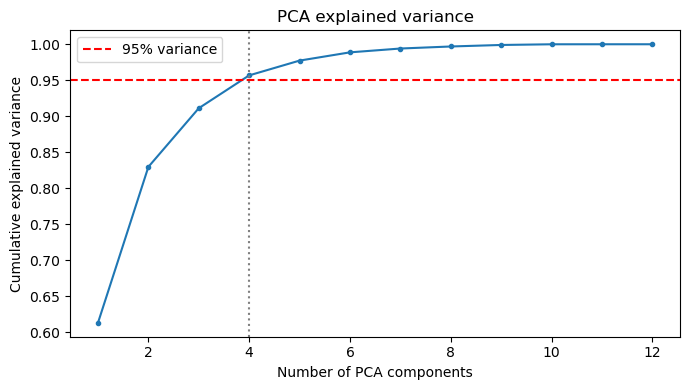

In [9]:
feature_cols = magnitude_cols          # decision from Section 4
X = data[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cum_var >= 0.95) + 1
print(f'Components needed for 95% variance: {n_components_95} (out of {X_scaled.shape[1]} features)')

pca = PCA(n_components=n_components_95)
X_pca = pca.fit_transform(X_scaled)
print('PCA-reduced shape:', X_pca.shape)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', markersize=3)
plt.axhline(0.95, color='red', linestyle='--', label='95% variance')
plt.axvline(n_components_95, color='gray', linestyle=':')
plt.xlabel('Number of PCA components'); plt.ylabel('Cumulative explained variance')
plt.title('PCA explained variance')
plt.legend()
plt.tight_layout()
plt.show()


## 6. Four Unsupervised Models

**K-Means** (partitional, hard assignment) and **Agglomerative Hierarchical Clustering**
(bottom-up, Ward linkage) assume compact, globular groupings and need `k` specified
(`n_clusters=2`, matching smooth/bumpy).

**Gaussian Mixture Model** (probabilistic) fits 2 Gaussian components; each window is assigned
to its most probable component (the "hardened" version of its soft output).

**DBSCAN** (density-based) needs no cluster count but is **very sensitive to `eps`**. The
k-distance-graph percentile heuristic from the course notes (90th percentile) landed in a
region where DBSCAN merges nearly everything into one blob. The sweep below shows how sharply
the result changes with `eps`, and `EPS_DBSCAN` is set from it.

> ⚠️ **Honesty note for the report:** the sweep table shows ARI/purity per `eps`, so choosing
> `EPS_DBSCAN` from it uses knowledge of the labels — DBSCAN's number here is best read as
> "what DBSCAN *can* do when well-tuned", not a label-free result. The fact that it only works
> in a narrow `eps` band is itself a finding about DBSCAN's practicality for this task.

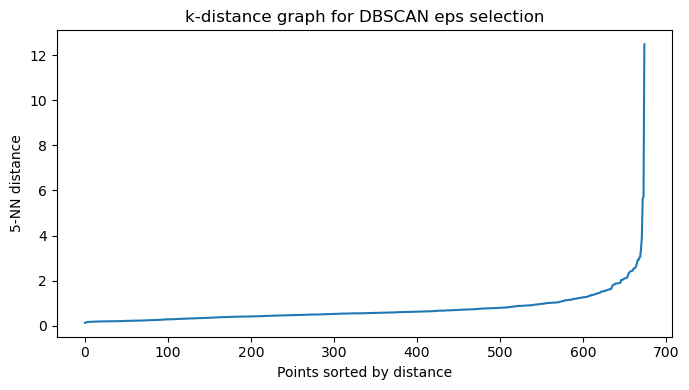

k-distance percentiles: {50: 0.55, 60: 0.63, 70: 0.74, 80: 0.92, 90: 1.31, 95: 1.87}


,eps,n_clusters,noise_pct,ARI,purity
0,0.3,5,77.8,0.416,0.847
1,0.4,10,62.2,0.476,0.917
2,0.5,6,47.3,0.405,0.938
3,0.6,6,32.7,0.442,0.950
4,0.8,2,18.8,-0.037,0.649
5,1.0,2,12.4,-0.027,0.652
6,1.3,2,7.3,-0.040,0.649


In [10]:
min_samples = 5
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(k_dist)
plt.xlabel('Points sorted by distance'); plt.ylabel(f'{min_samples}-NN distance')
plt.title('k-distance graph for DBSCAN eps selection')
plt.tight_layout()
plt.show()

print('k-distance percentiles:', {p: round(float(np.percentile(k_dist, p)), 2) for p in (50, 60, 70, 80, 90, 95)})

# eps sensitivity sweep
sweep = []
for eps in [0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.3]:
    l = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_pca)
    sweep.append(dict(eps=eps,
                      n_clusters=len(set(l)) - (1 if -1 in l else 0),
                      noise_pct=round((l == -1).mean() * 100, 1),
                      ARI=round(adjusted_rand_score(y_true, l), 3),
                      purity=round(purity_score(y_true, l), 3)))
pd.DataFrame(sweep)


In [11]:
EPS_DBSCAN = 0.6   # chosen from the sweep above (see honesty note)

results = []

km = KMeans(n_clusters=2, n_init=10, random_state=42)
results.append(('K-Means', km.fit_predict(X_pca)))

agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
results.append(('Agglomerative', agg.fit_predict(X_pca)))

db = DBSCAN(eps=EPS_DBSCAN, min_samples=min_samples)
results.append(('DBSCAN', db.fit_predict(X_pca)))

gmm = GaussianMixture(n_components=2, random_state=42)
results.append(('GMM', gmm.fit_predict(X_pca)))

print(f"{'Model':15s} {'n_clusters':>10s} {'noise%':>8s} {'silhouette':>11s} {'ARI':>8s} {'purity':>8s}")
for name, labels in results:
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).mean() * 100 if -1 in labels else 0.0
    mask = labels != -1
    sil = silhouette_score(X_pca[mask], labels[mask]) if len(set(labels[mask])) > 1 else float('nan')
    ari = adjusted_rand_score(y_true, labels)
    purity = purity_score(y_true, labels)
    print(f"{name:15s} {n_clusters:10d} {noise_pct:7.1f}% {sil:11.3f} {ari:8.3f} {purity:8.3f}")
    data[f'cluster_{name.lower().replace("-","")}'] = labels


Model           n_clusters   noise%  silhouette      ARI   purity
K-Means                  2     0.0%       0.477    0.715    0.923
Agglomerative            2     0.0%       0.472    0.856    0.963
DBSCAN                   6    32.7%       0.262    0.442    0.950
GMM                      2     0.0%       0.446    0.775    0.941


c:\Users\Himanshu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Himanshu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


## 7. Visual Comparison (PCA 2D Projection)

Projecting onto the first two principal components lets you eyeball what each model
actually did, side by side with the ground truth. Note this 2D view is a simplification
(it's only 2 of the `n_components_95` dimensions actually used for clustering), so a
model can look "wrong" here while still having used real separation in a dimension not
shown — treat this as an intuition aid, not the full picture.

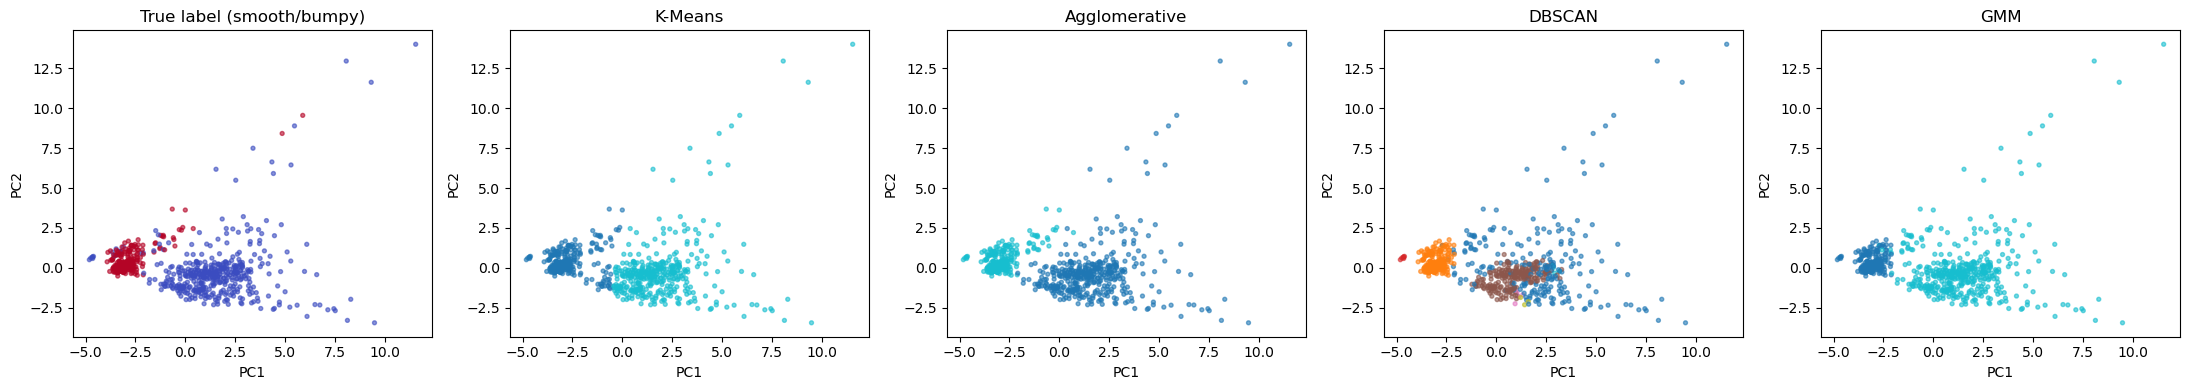

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='coolwarm', s=8, alpha=0.6)
axes[0].set_title('True label (smooth/bumpy)')
for ax, (name, labels) in zip(axes[1:], results):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=8, alpha=0.6)
    ax.set_title(name)
for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()


## 8. Diagnostic: Do the Clusters Reflect Road Quality, or Something Else?

A model can score well internally (tight, well-separated clusters by its own geometric
measure) while having found structure that has nothing to do with the actual class of
interest. Cross-tabulating cluster assignment against **participant** (not just against
the true label) is how you catch this.

In [13]:
for name, labels in results:
    col = f'cluster_{name.lower().replace("-","")}'
    print(f'\n=== {name}: cluster vs participant ===')
    print(pd.crosstab(data['participant'], data[col]))
    print(f'=== {name}: cluster vs label ===')
    print(pd.crosstab(data['label'], data[col]))



=== K-Means: cluster vs participant ===
cluster_kmeans    0    1
participant             
Aniket          132  180
Himanshu        106  143
Yuhan            45   69
=== K-Means: cluster vs label ===
cluster_kmeans    0    1
label                   
bumpy            49  389
smooth          234    3

=== Agglomerative: cluster vs participant ===
cluster_agglomerative    0    1
participant                    
Aniket                 186  126
Himanshu               164   85
Yuhan                   69   45
=== Agglomerative: cluster vs label ===
cluster_agglomerative    0    1
label                          
bumpy                  416   22
smooth                   3  234

=== DBSCAN: cluster vs participant ===
cluster_dbscan   -1    0   1   2   3   4   5
participant                                 
Aniket           96  113   0  98   0   0   5
Himanshu        100   66   6  70   4   3   0
Yuhan            25   40   0  49   0   0   0
=== DBSCAN: cluster vs label ===
cluster_dbscan   -1    0   

**What to look for when you re-run this on your own group's data:** if a model's
cluster boundaries split cleanly along *participant* lines rather than along *label*
lines — e.g. a small cluster that is 100% one person regardless of whether their
recordings are smooth or bumpy — that model has likely keyed off something about that
person's specific phone, mounting, or baseline vibration level, not road surface texture.
This matters because `StandardScaler` normalizes each *feature* globally across all
windows, but does **not** correct for a systematic per-participant shift (e.g. one
person's phone consistently reading higher acceleration magnitudes than another's,
independent of the road) — so density- and probability-based methods, which are
sensitive to local sub-populations, can end up separating people rather than surface
conditions, even when the overall accuracy-like metrics (purity) look passable.

If you see this pattern, it is worth writing up explicitly in the "Data quality
assessment and limitations" section — it is a real methodological finding, not a mistake
to hide.

## 9. Unsupervised Results — Interpretation & Caveats

**Results on the final data (re-recorded smooth rides, magnitude-only features, 675 windows):**

| Model | ARI | Purity | Notes |
|---|---|---|---|
| Agglomerative (Ward) | **0.856** | **0.963** | Best. Captures 234/237 smooth windows in one cluster and 416/438 bumpy in the other |
| GMM | 0.775 | 0.941 | Large jump vs. the all-feature version (0.465) once orientation features were removed |
| K-Means | 0.715 | 0.923 | Solid, but assigns 49 bumpy windows to the smooth-like cluster |
| DBSCAN (eps=0.6) | 0.442 | 0.950 | Only works in a narrow eps band; flags 33% of windows as noise |

**What changed vs. the first run, and why it matters for the report:**
1. *Re-recorded smooth rides* (Himanshu, Aniket) fixed a **lane-selection** problem: their
   first "smooth" rides had imperfections and looked nearly as rough as bumpy rides.
   Agglomerative ARI rose 0.585 → 0.856 from this alone.
2. *Dropping orientation-dependent features* fixed a **placement** problem: gravity features
   encode phone tilt, and Yuhan's smooth ride was tilted ~49° vs. ~2-23° for the other rides.
   Section 8's cross-tabs now show every cluster spread across all three participants — no
   cluster is a single person any more, which was the failure signature before.
3. These are two *different* data-quality issues that looked similar at first glance
   (both showed up as "one participant's data is an outlier"). Separating them required
   checking actual numbers, not assuming — worth stating in "Data quality assessment".

**Reading DBSCAN:** with `eps=0.6`, cluster 0 is an almost pure smooth core (211 smooth vs. 8
bumpy) and cluster 2 an almost pure bumpy group (217/217), but 195 of 438 bumpy windows end
up as noise. Smooth riding is uniform and forms one dense region; bumpy riding is more
varied, so density-based methods struggle to group all of it. That is a real
advantage/limitation to discuss, alongside the eps sensitivity shown in Section 6.

**Per-model discussion to write up** (assignment: problem suitability, data requirements,
interpretability, computational efficiency): Ward-linkage hierarchical clustering suited this
data best, likely because smooth vs. bumpy separates mainly along one axis (vibration
intensity) that a compact-cluster assumption handles well. Hard-assignment methods
(K-Means, Agglomerative) are easiest to explain to a city planner; GMM additionally offers
per-window probabilities (`gmm.predict_proba`) which could flag borderline road sections.

**Known limitations:**
- Only 3 participants / 6 rides — results describe *these* rides, not road quality in general.
  Evaluation is in-sample (clustering was fit on all windows; labels used only to score).
- The feature-set choice (Section 4) and DBSCAN `eps` (Section 6) were made while looking at
  label-based scores, so they carry mild optimism. The supervised stage should use
  leave-one-recording-out CV to give an unbiased estimate.
- Time-domain features only — frequency-domain (FFT) features are still to be tried.
- Phone placement is still not perfectly standardized (tilt ranges ~2-23° across rides);
  magnitude features are robust to this, but it should be documented in the protocol section.

The supervised stage (Sections 10-14) addresses the in-sample limitation directly, using leave-one-participant-out validation.


## 10. Supervised Learning — Setup

**Task:** classify each 2s window as **smooth (0)** or **bumpy (1)**; *bumpy is the positive class*.

**Models (4):** Logistic Regression (linear), Decision Tree (single tree), Random Forest
(tree ensemble), Support Vector Machine with RBF kernel (kernel method) — four different model
families, so the comparison says something. (Linear Regression was not used: it predicts
continuous values, not classes. k-NN is a drop-in alternative.)

**Validation — leave-one-participant-out (LOPO):** train on two participants, test on the third,
repeat three times. This is much stricter than a random split: windows from the same ride are
near-duplicates of each other (50% overlap), so a random split leaks and inflates scores.
LOPO also tests what deployment needs — working on a person/phone/route the model has never seen.

**Tuning — nested:** inside every training set, hyperparameters are chosen with
`GridSearchCV` and an inner `GroupKFold` (also grouped by participant), scored by macro-F1.
The held-out participant is never used for tuning or scaling.

**Class imbalance** (438 bumpy vs. 237 smooth windows): handled with `class_weight='balanced'`
and by reporting balanced accuracy / macro-F1 alongside accuracy.

**Leakage control:** scaling and feature selection live *inside* the sklearn `Pipeline`, so they
are re-fit on training data only for every fold.

In [14]:
# Supervised-learning imports (all part of scikit-learn, already used above)
import time, os
import joblib
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             confusion_matrix, classification_report)

y_bin  = (data['label'] == 'bumpy').astype(int).values   # 1 = bumpy (positive class)
groups = data['participant'].values                       # LOPO groups
participants = sorted(data['participant'].unique())
X_sup = data[magnitude_cols].values                       # 12 orientation-invariant features (Section 4)

print('Class balance (0=smooth, 1=bumpy):', dict(pd.Series(y_bin).value_counts()))
print('Participants (LOPO folds):', participants)


Class balance (0=smooth, 1=bumpy): {1: np.int64(438), 0: np.int64(237)}
Participants (LOPO folds): ['Aniket', 'Himanshu', 'Yuhan']


## 11. Feature Engineering Check — Frequency-Domain Features

Road roughness is vibration, so frequency content is a natural candidate. The assignment asks
for feature extraction beyond simple statistics, so this section tests it properly (same LOPO
scheme, same magnitude signals): dominant frequency, energy in four frequency bands, spectral
entropy and zero-crossing rate, for both `acc_mag` and `gyro_mag` (14 features).

Feature sets are compared with default hyperparameters so the comparison is about the
*features*, not tuning.

In [15]:
FS = 100   # sampling rate (Hz)

def freq_features(sig, prefix):
    """Orientation-invariant spectral features of one magnitude signal (one window)."""
    s = sig - sig.mean()
    power = np.abs(np.fft.rfft(s)) ** 2
    freqs = np.fft.rfftfreq(len(s), 1 / FS)
    total = power.sum() + 1e-12
    f = {prefix + '_dom_freq': freqs[1:][np.argmax(power[1:])]}
    for lo, hi in [(0.5, 5), (5, 15), (15, 30), (30, 50)]:
        f[f'{prefix}_band_{lo}_{hi}'] = power[(freqs >= lo) & (freqs < hi)].sum() / total
    p = power[1:] / (power[1:].sum() + 1e-12)
    f[prefix + '_spec_entropy'] = -(p * np.log(p + 1e-12)).sum()
    f[prefix + '_zcr'] = ((s[:-1] * s[1:]) < 0).mean()
    return f

rows = []
for rec in RECORDINGS:                      # same order/windowing as `data`
    key = f"{rec['participant']}_{rec['label']}"
    wins, _ = make_windows(trimmed_recordings[key])
    for win in wins:
        am = np.sqrt(win['acc_x']**2 + win['acc_y']**2 + win['acc_z']**2).values
        gm = np.sqrt(win['gyro_x']**2 + win['gyro_y']**2 + win['gyro_z']**2).values
        f = {}
        f.update(freq_features(am, 'acc_mag')); f.update(freq_features(gm, 'gyro_mag'))
        rows.append(f)
freq_df = pd.DataFrame(rows)
assert len(freq_df) == len(data), 'window order mismatch'
freq_cols = list(freq_df.columns)

def lopo_macro_f1(X, estimator):
    """Mean macro-F1 over leave-one-participant-out folds (default hyperparameters)."""
    scores = []
    for held in participants:
        tr = groups != held
        pipe = Pipeline([('scale', StandardScaler()), ('clf', estimator)]).fit(X[tr], y_bin[tr])
        scores.append(f1_score(y_bin[~tr], pipe.predict(X[~tr]), average='macro'))
    return np.mean(scores)

X_time = data[magnitude_cols].values
X_freq = freq_df[freq_cols].values
X_both = np.hstack([X_time, X_freq])

quick = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=3, class_weight='balanced', random_state=42),
    'SVM (RBF)': SVC(class_weight='balanced'),
}
tab = pd.DataFrame({name: {'time-domain (12)': lopo_macro_f1(X_time, est),
                           'frequency-domain (14)': lopo_macro_f1(X_freq, est),
                           'time + frequency (26)': lopo_macro_f1(X_both, est)}
                    for name, est in quick.items()})
tab.round(3)


,Logistic Regression,Random Forest,SVM (RBF)
time-domain (12),0.960,0.953,0.954
frequency-domain (14),0.688,0.804,0.737
time + frequency (26),0.913,0.952,0.931


**Result: frequency-domain features did not help.** On their own they are much weaker than
the time-domain statistics, and adding them to the time-domain set leaves performance flat or
worse (Logistic Regression drops from 0.96 to 0.91) — more features, no extra information, more
room to overfit with only ~675 windows. The time-domain magnitude features are kept. This negative result is worth stating
in the report — it shows the feature choice was tested, not assumed.

## 12. Feature Selection

Three independent rankings of the 12 magnitude features: ANOVA F-score (linear separation),
mutual information (any dependence), and Random-Forest importance (non-linear, multivariate).
Rankings are descriptive (computed on all data); the *performance* impact of using fewer
features is then tested properly, with selection done **inside** each LOPO training fold.

,ANOVA_F,MutualInfo,RF_importance,avg_rank
acc_mag_rms,1133.190,0.550,0.208,2.333
acc_mag_std,889.470,0.547,0.240,2.667
acc_mag_mean,1155.519,0.540,0.156,3.000
acc_mag_iqr,827.760,0.552,0.141,3.333
acc_mag_max,572.893,0.556,0.084,4.000
gyro_mag_max,322.640,0.448,0.100,5.667
gyro_mag_std,165.740,0.329,0.030,8.000
gyro_mag_mean,224.486,0.308,0.008,8.333
gyro_mag_rms,214.856,0.325,0.016,8.333
acc_mag_min,219.690,0.261,0.007,9.333


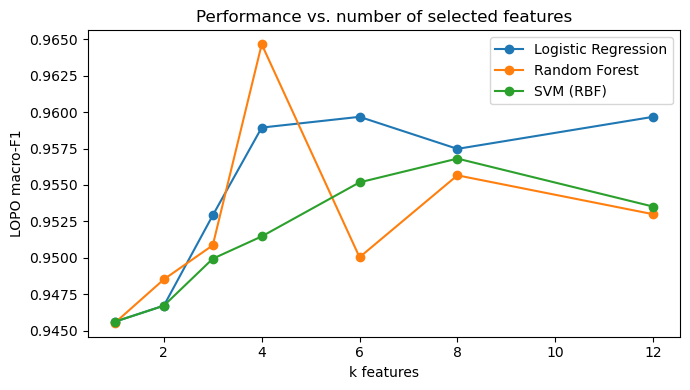

,Logistic Regression,Random Forest,SVM (RBF)
k features,,,
1,0.946,0.946,0.946
2,0.947,0.949,0.947
3,0.953,0.951,0.950
4,0.959,0.965,0.951
6,0.960,0.950,0.955
8,0.957,0.956,0.957
12,0.960,0.953,0.954


In [16]:
Xs_all = StandardScaler().fit_transform(X_sup)
F_scores, _ = f_classif(Xs_all, y_bin)
MI_scores = mutual_info_classif(Xs_all, y_bin, random_state=0)
RF_scores = RandomForestClassifier(n_estimators=300, max_depth=4, class_weight='balanced',
                                   random_state=0).fit(Xs_all, y_bin).feature_importances_

ranking = pd.DataFrame({'ANOVA_F': F_scores, 'MutualInfo': MI_scores, 'RF_importance': RF_scores}, index=magnitude_cols)
ranking['avg_rank'] = ranking[['ANOVA_F', 'MutualInfo', 'RF_importance']].rank(ascending=False).mean(axis=1)
ranking = ranking.sort_values('avg_rank')
display(ranking.round(3))

# Performance vs number of features, selection INSIDE each training fold (no leakage)
ks = [1, 2, 3, 4, 6, 8, 12]
def lopo_with_k(k, estimator):
    scores = []
    for held in participants:
        tr = groups != held
        pipe = Pipeline([('scale', StandardScaler()), ('select', SelectKBest(f_classif, k=k)), ('clf', estimator)])
        pipe.fit(X_sup[tr], y_bin[tr])
        scores.append(f1_score(y_bin[~tr], pipe.predict(X_sup[~tr]), average='macro'))
    return np.mean(scores)

k_curve = pd.DataFrame({name: [lopo_with_k(k, est) for k in ks] for name, est in quick.items()}, index=ks)
k_curve.index.name = 'k features'
ax = k_curve.plot(marker='o', figsize=(7, 4))
ax.set_ylabel('LOPO macro-F1'); ax.set_title('Performance vs. number of selected features')
plt.tight_layout(); plt.show()
k_curve.round(3)


**Optimal features:** the accelerometer-magnitude statistics — `acc_mag` RMS, std, mean, IQR
and max — rank at the top under all three methods. **A single feature already reaches
macro-F1 ≈ 0.95 on unseen participants, and 4-6 features reach the plateau (~0.96)**;
gyroscope features add little. Physically that makes sense: bumpy lanes produce stronger
vertical-ish shocks, and overall vibration *intensity* is what separates the classes.

Because of this plateau, the number of features `k` (SelectKBest, ANOVA F) is treated as a
**hyperparameter tuned inside the nested CV** in the next section, with `k ∈ {4, 6, 12}`.

## 13. Four Supervised Models — Nested Leave-One-Participant-Out

Pipeline per model: `StandardScaler → SelectKBest(k) → classifier`. Hyperparameter grids are
deliberately small (≈675 windows; large grids would mostly fit noise):

| Model | Tuned hyperparameters |
|---|---|
| Logistic Regression | `C` (regularization strength), `k` |
| Decision Tree | `max_depth`, `min_samples_leaf`, `k` |
| Random Forest | `n_estimators`, `max_depth`, `k` |
| SVM (RBF) | `C`, `gamma`, `k` |

In [17]:
K_GRID = [4, 6, 12]

model_specs = {
    'Logistic Regression': (LogisticRegression(max_iter=2000, class_weight='balanced'),
                            {'clf__C': [0.1, 1, 10], 'select__k': K_GRID}),
    'Decision Tree':       (DecisionTreeClassifier(class_weight='balanced', random_state=42),
                            {'clf__max_depth': [2, 3, 5, 8], 'clf__min_samples_leaf': [5, 15], 'select__k': K_GRID}),
    'Random Forest':       (RandomForestClassifier(class_weight='balanced', random_state=42),
                            {'clf__n_estimators': [100, 300], 'clf__max_depth': [3, 6, None], 'select__k': K_GRID}),
    'SVM (RBF)':           (SVC(class_weight='balanced'),
                            {'clf__C': [0.1, 1, 10], 'clf__gamma': ['scale', 0.1], 'select__k': K_GRID}),
}

def make_pipe(est):
    return Pipeline([('scale', StandardScaler()), ('select', SelectKBest(f_classif)), ('clf', est)])

fold_rows, oof_pred, fold_models = [], {}, {}
for name, (est, grid) in model_specs.items():
    oof_pred[name] = np.zeros(len(y_bin), dtype=int)          # out-of-fold predictions
    for held in participants:
        tr, te = groups != held, groups == held
        gs = GridSearchCV(make_pipe(est), grid, cv=GroupKFold(n_splits=2), scoring='f1_macro')
        gs.fit(X_sup[tr], y_bin[tr], groups=groups[tr])        # inner CV: tuning only on training participants
        pred = gs.predict(X_sup[te])
        oof_pred[name][te] = pred
        fold_models[(name, held)] = gs.best_estimator_
        fold_rows.append(dict(model=name, held_out=held,
                              accuracy=accuracy_score(y_bin[te], pred),
                              balanced_acc=balanced_accuracy_score(y_bin[te], pred),
                              macro_F1=f1_score(y_bin[te], pred, average='macro'),
                              best_params=str(gs.best_params_)))

fold_results = pd.DataFrame(fold_rows)
display(fold_results.drop(columns='best_params').round(3))
summary = fold_results.groupby('model')[['accuracy', 'balanced_acc', 'macro_F1']].agg(['mean', 'std']).round(3)
summary


,model,held_out,accuracy,balanced_acc,macro_F1
0,Logistic Regression,Aniket,0.978,0.982,0.977
1,Logistic Regression,Himanshu,0.928,0.933,0.916
2,Logistic Regression,Yuhan,0.974,0.979,0.972
3,Decision Tree,Aniket,0.974,0.975,0.973
4,Decision Tree,Himanshu,0.924,0.930,0.912
5,Decision Tree,Yuhan,0.895,0.883,0.887
6,Random Forest,Aniket,0.981,0.981,0.980
7,Random Forest,Himanshu,0.936,0.947,0.926
8,Random Forest,Yuhan,0.974,0.979,0.972
9,SVM (RBF),Aniket,0.978,0.980,0.977


accuracy        balanced_acc        macro_F1       
                        mean    std         mean    std     mean    std
model                                                                  
Decision Tree          0.931  0.040        0.929  0.046    0.924  0.044
Logistic Regression    0.960  0.028        0.964  0.027    0.955  0.034
Random Forest          0.963  0.024        0.969  0.019    0.959  0.029
SVM (RBF)              0.961  0.025        0.968  0.021    0.957  0.031

In [18]:
# Per-participant macro-F1 (does any model fail on one person?)
fold_results.pivot(index='model', columns='held_out', values='macro_F1').round(3).assign(
    mean=lambda d: d.mean(axis=1).round(3)).sort_values('mean', ascending=False)


held_out,Aniket,Himanshu,Yuhan,mean
model,,,,
Random Forest,0.980,0.926,0.972,0.959
SVM (RBF),0.977,0.921,0.972,0.957
Logistic Regression,0.977,0.916,0.972,0.955
Decision Tree,0.973,0.912,0.887,0.924


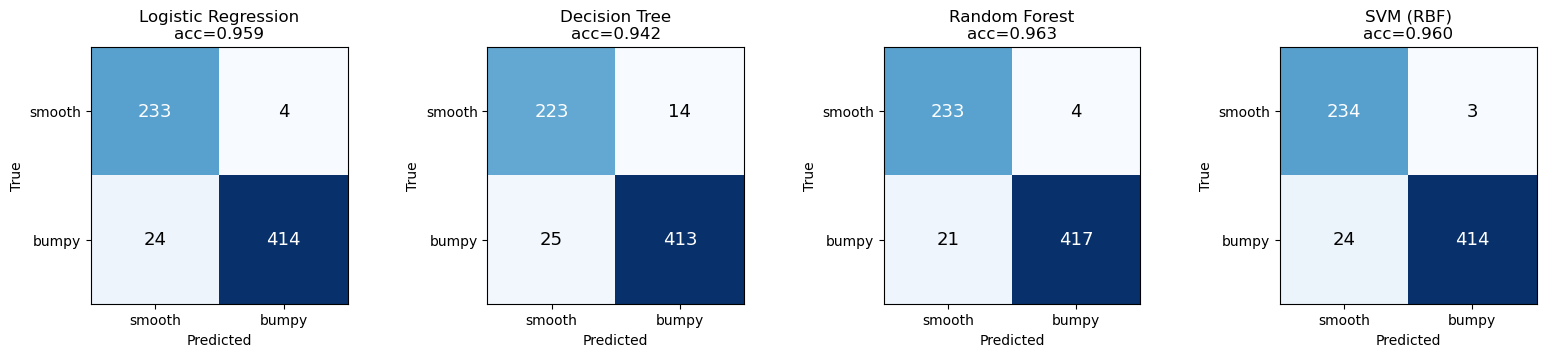

Best hyperparameters chosen per fold:


,model,held_out,best_params
0,Logistic Regression,Aniket,"{'clf__C': 1, 'select__k': 6}"
1,Logistic Regression,Himanshu,"{'clf__C': 10, 'select__k': 12}"
2,Logistic Regression,Yuhan,"{'clf__C': 1, 'select__k': 4}"
3,Decision Tree,Aniket,"{'clf__max_depth': 2, 'clf__min_samples_leaf':..."
4,Decision Tree,Himanshu,"{'clf__max_depth': 3, 'clf__min_samples_leaf':..."
5,Decision Tree,Yuhan,"{'clf__max_depth': 2, 'clf__min_samples_leaf':..."
6,Random Forest,Aniket,"{'clf__max_depth': 6, 'clf__n_estimators': 300..."
7,Random Forest,Himanshu,"{'clf__max_depth': 3, 'clf__n_estimators': 300..."
8,Random Forest,Yuhan,"{'clf__max_depth': 6, 'clf__n_estimators': 100..."
9,SVM (RBF),Aniket,"{'clf__C': 10, 'clf__gamma': 0.1, 'select__k':..."


In [19]:
# Confusion matrices from pooled out-of-fold predictions (every window predicted by a model that never saw its participant)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, (name, pred) in zip(axes, oof_pred.items()):
    cm = confusion_matrix(y_bin, pred)
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=13,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['smooth', 'bumpy']); ax.set_yticks([0, 1]); ax.set_yticklabels(['smooth', 'bumpy'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f"{name}\nacc={accuracy_score(y_bin, pred):.3f}")
plt.tight_layout(); plt.show()

print('Best hyperparameters chosen per fold:')
display(fold_results[['model', 'held_out', 'best_params']])


## 14. Model Comparison, Selection & Justification

**Selection rule (fixed before looking at the winner):** take the model with the best mean LOPO
macro-F1; among all models within **0.01 F1** of it (differences that small are within noise
with only 3 folds), pick the *simplest and most interpretable* one.

Each model is then re-tuned on all data (inner `GroupKFold` over the 3 participants) to produce the
final deployable version, and its training/inference cost is measured.

In [20]:
SIMPLICITY_ORDER = ['Logistic Regression', 'Decision Tree', 'SVM (RBF)', 'Random Forest']   # simplest first
TOLERANCE = 0.01

mean_f1 = fold_results.groupby('model')['macro_F1'].mean()
best_score = mean_f1.max()
candidates = [m for m in SIMPLICITY_ORDER if mean_f1[m] >= best_score - TOLERANCE]
final_name = candidates[0]
print('Mean LOPO macro-F1:\n', mean_f1.round(3).to_string())
print(f'\nModels within {TOLERANCE} of the best ({best_score:.3f}): {candidates}')
print('=> Selected model:', final_name)

# Re-tune every model on ALL data (for timing + the deployable model) — inner CV grouped by participant
final_models, cost_rows = {}, []
for name, (est, grid) in model_specs.items():
    t0 = time.perf_counter()
    gs = GridSearchCV(make_pipe(est), grid, cv=GroupKFold(n_splits=3), scoring='f1_macro')
    gs.fit(X_sup, y_bin, groups=groups)
    fit_s = time.perf_counter() - t0
    final_models[name] = gs.best_estimator_
    t0 = time.perf_counter()
    for _ in range(20):
        gs.best_estimator_.predict(X_sup)
    per_window_us = (time.perf_counter() - t0) / (20 * len(X_sup)) * 1e6
    cost_rows.append(dict(model=name, tuning_time_s=round(fit_s, 1), inference_us_per_window=round(per_window_us, 1)))
cost = pd.DataFrame(cost_rows).set_index('model')


Mean LOPO macro-F1:
 model
Decision Tree          0.924
Logistic Regression    0.955
Random Forest          0.959
SVM (RBF)              0.957

Models within 0.01 of the best (0.959): ['Logistic Regression', 'SVM (RBF)', 'Random Forest']
=> Selected model: Logistic Regression


In [21]:
# Full comparison table: all five assignment criteria in one place
n_feat = {m: final_models[m].named_steps['select'].k for m in final_models}
criteria = pd.DataFrame({
    'LOPO macro-F1 (mean)': mean_f1.round(3),
    'LOPO accuracy (mean)': fold_results.groupby('model')['accuracy'].mean().round(3),
    'inference µs/window': cost['inference_us_per_window'],
    'tuning time (s)': cost['tuning_time_s'],
    'features used (k)': pd.Series(n_feat),
}).loc[SIMPLICITY_ORDER]
criteria['interpretability'] = ['High: one weight per feature', 'High: readable if-then rules',
                                'Low: kernel, no direct weights', 'Low-medium: importances only']
criteria


,LOPO macro-F1 (mean),LOPO accuracy (mean),inference µs/window,tuning time (s),features used (k),interpretability
Logistic Regression,0.955,0.960,0.9,0.3,6,High: one weight per feature
Decision Tree,0.924,0.931,1.0,0.5,12,High: readable if-then rules
SVM (RBF),0.957,0.961,3.6,0.4,12,"Low: kernel, no direct weights"
Random Forest,0.959,0.963,10.8,14.4,4,Low-medium: importances only


In [22]:
# Interpretability of the selected model: which features push a window toward "bumpy"?
lr = final_models['Logistic Regression']
selected = np.array(magnitude_cols)[lr.named_steps['select'].get_support()]
coefs = pd.Series(lr.named_steps['clf'].coef_[0], index=selected).sort_values(ascending=False)
print('Logistic-regression coefficients (standardized features; positive = more bumpy):')
print(coefs.round(3).to_string())


Logistic-regression coefficients (standardized features; positive = more bumpy):
acc_mag_std     1.859
acc_mag_max     1.308
acc_mag_iqr     1.235
gyro_mag_max    0.635
acc_mag_rms     0.608
acc_mag_mean    0.063


### Error Analysis — Where Does the Selected Model Fail?

The report needs failure modes, not just scores. Below: errors per recording, and errors split by
*when in the ride* the window occurs.

Errors made by Logistic Regression: 28 of 675 windows


,errors,windows,error_rate
recording,,,
Aniket_bumpy,7,191,0.037
Aniket_smooth,0,121,0.000
Himanshu_bumpy,14,176,0.080
Himanshu_smooth,4,73,0.055
Yuhan_bumpy,3,71,0.042
Yuhan_smooth,0,43,0.000


errors  windows  error_rate
ride_phase label                              
first 10 s bumpy       17       30       0.567
           smooth       2       30       0.067
last 10 s  bumpy        6       30       0.200
           smooth       2       30       0.067
middle     bumpy        1      378       0.003
           smooth       0      177       0.000

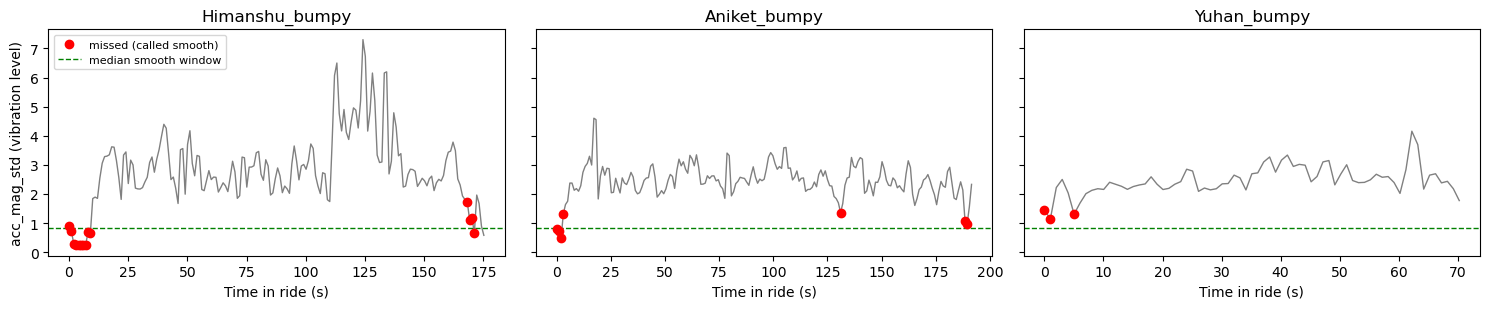

In [23]:
err_df = data[['recording', 'label', 'window_start_t', 'acc_mag_std']].copy()
err_df['error'] = oof_pred[final_name] != y_bin            # out-of-fold, so honest
t_end = err_df.groupby('recording')['window_start_t'].transform('max')
err_df['ride_phase'] = np.select([err_df['window_start_t'] < 10, err_df['window_start_t'] > t_end - 10],
                                 ['first 10 s', 'last 10 s'], default='middle')

print(f'Errors made by {final_name}: {err_df["error"].sum()} of {len(err_df)} windows')
display(err_df.groupby('recording')['error'].agg(errors='sum', windows='count', error_rate='mean').round(3))
display(err_df.groupby(['ride_phase', 'label'])['error'].agg(errors='sum', windows='count', error_rate='mean').round(3))

# Vibration level over time for each bumpy ride, missed windows marked
fig, axes = plt.subplots(1, 3, figsize=(15, 3.2), sharey=True)
for ax, rec in zip(axes, [r for r in err_df['recording'].unique() if r.endswith('bumpy')]):
    g = err_df[err_df['recording'] == rec]
    ax.plot(g['window_start_t'], g['acc_mag_std'], color='gray', lw=1)
    miss = g[g['error']]
    ax.scatter(miss['window_start_t'], miss['acc_mag_std'], color='red', zorder=3, label='missed (called smooth)')
    ax.axhline(err_df.loc[err_df['label'] == 'smooth', 'acc_mag_std'].median(), color='green', ls='--', lw=1, label='median smooth window')
    ax.set_title(rec); ax.set_xlabel('Time in ride (s)')
axes[0].set_ylabel('acc_mag_std (vibration level)'); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()


**Findings (numbers from this run):**
- Errors are concentrated at the **edges of rides**: 27 of the 28 errors fall in the first or last 10 s. In the first 10 s,
  17 of 30 bumpy windows are missed; in the last 10 s, 6 of 30. **In the middle of rides there is 1 error in 555 windows (0.2%).**
- The missed bumpy windows have a vibration level (median `acc_mag_std` ≈ 0.75) almost identical to smooth windows
  (≈ 0.82) — the model behaves sensibly on them, because the *signal itself* looks smooth.
- **Likely explanation (not verified — speed was not recorded):** vibration amplitude scales with speed. While the rider
  is pulling away or slowing to a stop, even a bumpy lane produces gentle shaking. GPS speed would let us test this directly.
- Smooth windows are almost never called bumpy (4 of 237 in total).

**Implications:** (1) in deployment, low-speed segments (start-ups, stops, junctions) are unreliable — flag or skip them
if speed is available; (2) a longer edge trim would remove most errors, but that was found *after* seeing the errors, so it
is reported as an observation and **not** applied to the scores above.

### Supervised vs. Unsupervised

| | Unsupervised (Sections 5-9) | Supervised (Sections 10-14) |
|---|---|---|
| Uses labels for training | No — labels only to score afterwards | Yes |
| Validation in this notebook | In-sample (clusters fit on all windows) | Leave-one-participant-out, nested tuning — stricter |
| Best result | Agglomerative: purity ≈ 0.96, ARI ≈ 0.86 | LOPO accuracy ≈ 0.96, macro-F1 ≈ 0.95 |
| Tuned hyperparameters | `eps`, `k`, number of PCA components | Grids per model, chosen by inner CV |

**Reading the comparison honestly:** the two headline numbers look similar, but they are *not* the same kind
of test — the supervised numbers are on people the model never saw, the unsupervised ones are in-sample.
That the supervised models hold ~0.96 under the stricter test is the stronger result.

**Advantages / limitations**
- *Unsupervised:* needs no labels (useful when surveying new cities where nobody has labeled lanes),
  and confirmed that smooth vs. bumpy is a real structure in the data, not something the labels imposed.
  But it cannot name its clusters, needs a hand-chosen `k`/`eps`, and DBSCAN was fragile (narrow `eps` band).
- *Supervised:* gives directly usable smooth/bumpy predictions with per-window probabilities, and can be
  validated honestly. But it needs labeled rides, and it inherits any label noise (a "smooth" ride that
  wasn't smooth — as happened with our first recordings — directly corrupts it).

**Which to prefer when:** supervised for deployment (a city wants a smooth/bumpy verdict per road section);
unsupervised for exploration, sanity-checking labels, and discovering additional surface types
(e.g. cobblestones, gravel) that nobody labeled.

### Model justification for the selected model

- **Problem suitability:** the classes separate mainly along one axis — vibration intensity — so a linear
  decision boundary is enough; the tests show the non-linear models (RF, SVM) gain nothing.
- **Data requirements:** ~675 windows / 3 participants is small; a low-capacity model with strong
  regularization is the safer fit, and Decision Tree (highest variance) was clearly the weakest.
- **Interpretability:** each feature has one signed weight (see coefficients above) — explainable to a city planner. (Several
  selected features are correlated, e.g. std/IQR/RMS, so read the weights as "this group of vibration-intensity features
  pushes toward bumpy", not as independent effects.)
- **Computational efficiency:** microseconds per window and no heavy state — feasible on a phone in real time.
- **Performance:** statistically tied with the best model on unseen participants (see table), so nothing is
  sacrificed for the simplicity.

## 15. Deployment — Classify a New Recording

`classify_folder()` is the complete inference path for a new, unlabeled recording: load and merge the
three sensor files → drop the first/last 1.5s (recorded files only; a live stream has no such start/end)
→ 2s causal windows with 1s stride → 12 magnitude features → model → smooth/bumpy per window
(plus `P(bumpy)` when the model provides it).

Windows use only samples up to their own end, so the same code works on a live stream: buffer 2s,
classify, slide 1s.

**Honest demo without the external dataset:** the model used below for Yuhan's rides is the one
trained in the LOPO loop **without any of Yuhan's data** — a genuine unseen-participant test.
The real external dataset is applied the same way (cell after the demo).

In [24]:
def classify_folder(folder, model, acc='Accelerometer.csv', grav='Gravity.csv', gyro='Gyroscope.csv',
                    trim_seconds=1.5):
    """Classify a sensor recording. Returns one row per 2s window with the predicted class."""
    raw = load_and_merge(f'{folder}/{acc}', f'{folder}/{grav}', f'{folder}/{gyro}')
    keep = raw[(raw['seconds_elapsed'] >= raw['seconds_elapsed'].min() + trim_seconds) &
               (raw['seconds_elapsed'] <= raw['seconds_elapsed'].max() - trim_seconds)].reset_index(drop=True)
    windows, _ = make_windows(keep)
    feats = pd.DataFrame([extract_features(w) for w in windows])[magnitude_cols]
    out = pd.DataFrame({
        'start_s': [w['seconds_elapsed'].iloc[0] for w in windows],     # seconds since the start of the raw recording
        'end_s':   [w['seconds_elapsed'].iloc[-1] for w in windows],
        'pred_bumpy': model.predict(feats.values),
    })
    if hasattr(model, 'predict_proba'):
        out['p_bumpy'] = model.predict_proba(feats.values)[:, 1]
    out['label'] = np.where(out['pred_bumpy'] == 1, 'bumpy', 'smooth')
    return out

def causal_smooth(pred, n=3):
    """Majority vote over the last n windows only (no future data) — steadies the plot, adds ~n-1 s of lag."""
    return (pd.Series(pred).rolling(n, min_periods=1).mean() >= 0.5).astype(int).values

def plot_timeline(res, title):
    fig, ax = plt.subplots(figsize=(12, 2.6))
    smooth_pred = causal_smooth(res['pred_bumpy'].values)
    for (s, e), p in zip(zip(res['start_s'], res['end_s']), smooth_pred):
        ax.axvspan(s, e, color='tab:red' if p else 'tab:green', alpha=0.35, lw=0)
    if 'p_bumpy' in res:
        ax.plot((res['start_s'] + res['end_s']) / 2, res['p_bumpy'], color='black', lw=1, label='P(bumpy)')
        ax.legend(loc='upper right')
    ax.set_ylim(0, 1); ax.set_xlabel('Time in ride (s)'); ax.set_title(title + '   (green = smooth, red = bumpy)')
    plt.tight_layout(); plt.show()


Yuhan smooth ride: 43 windows | 0% predicted bumpy | window accuracy 100.0%


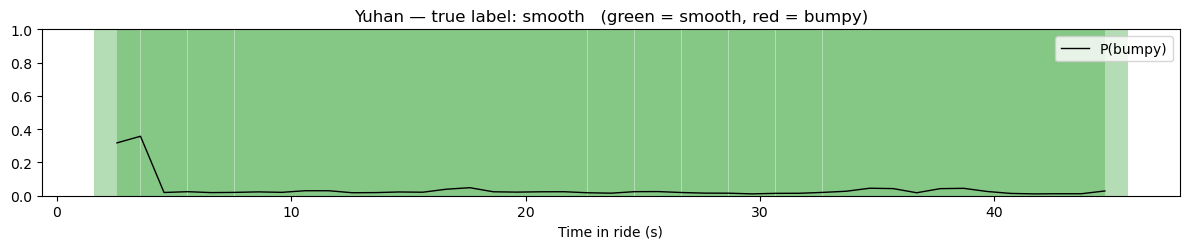

Yuhan bumpy  ride: 71 windows | 96% predicted bumpy | window accuracy 95.8%


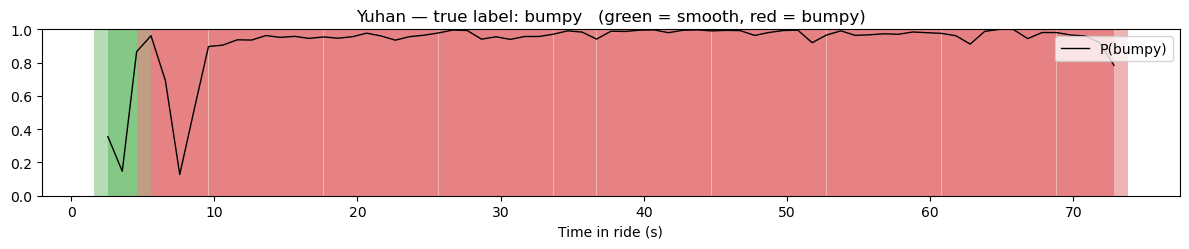

In [25]:
# Demo: rides of the held-out participant, classified by the model that never saw them
DEMO_PARTICIPANT = 'Yuhan'
demo_model = fold_models[(final_name, DEMO_PARTICIPANT)]

for rec in RECORDINGS:
    if rec['participant'] != DEMO_PARTICIPANT:
        continue
    res = classify_folder(rec['folder'], demo_model, rec['acc'], rec['grav'], rec['gyro'])
    frac_bumpy = res['pred_bumpy'].mean()
    correct = (res['pred_bumpy'] == (1 if rec['label'] == 'bumpy' else 0)).mean()
    print(f"{DEMO_PARTICIPANT} {rec['label']:6s} ride: {len(res)} windows | {frac_bumpy:.0%} predicted bumpy | window accuracy {correct:.1%}")
    plot_timeline(res, f"{DEMO_PARTICIPANT} — true label: {rec['label']}")


In [26]:
# Route map: if the recording folder also contains Location.csv (GPS), colour the route by prediction.
def plot_route(folder, res, trim_seconds=1.5):
    loc_path = f'{folder}/Location.csv'
    if not os.path.exists(loc_path):
        print('No Location.csv in this folder — showing the timeline only.')
        return
    loc = pd.read_csv(loc_path)
    t_mid = (res['start_s'] + res['end_s']) / 2 + trim_seconds          # back to raw-recording time
    lat = np.interp(t_mid, loc['seconds_elapsed'], loc['latitude'])
    lon = np.interp(t_mid, loc['seconds_elapsed'], loc['longitude'])
    smooth_pred = causal_smooth(res['pred_bumpy'].values)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(lon, lat, color='lightgray', lw=1, zorder=1)
    ax.scatter(lon[smooth_pred == 0], lat[smooth_pred == 0], c='tab:green', s=25, label='smooth', zorder=2)
    ax.scatter(lon[smooth_pred == 1], lat[smooth_pred == 1], c='tab:red', s=25, label='bumpy', zorder=2)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_aspect('equal'); ax.legend()
    ax.set_title('Predicted bike-lane quality along the route')
    plt.tight_layout(); plt.show()

# --- EXTERNAL DATASET: set this when the instructors' dataset arrives ---
EXTERNAL_FOLDER = 'data_external/<external_folder>'   # folder with Accelerometer/Gravity/Gyroscope(.csv) [+ Location.csv]
FINAL_DEPLOY_MODEL = final_models[final_name]          # tuned on ALL our data (Section 14)

if os.path.exists(EXTERNAL_FOLDER):
    ext = classify_folder(EXTERNAL_FOLDER, FINAL_DEPLOY_MODEL)
    print(ext['label'].value_counts())
    plot_timeline(ext, 'External dataset')
    plot_route(EXTERNAL_FOLDER, ext)
    ext.to_csv('external_predictions.csv', index=False)
else:
    print('External dataset path not set yet — the held-out-participant demo above shows the same code on unseen data.')

os.makedirs('models', exist_ok=True)
joblib.dump({'model': FINAL_DEPLOY_MODEL, 'features': magnitude_cols, 'window': WINDOW, 'stride': STRIDE},
            'models/bike_lane_model.joblib')
print('Saved deployable model bundle -> models/bike_lane_model.joblib')


External dataset path not set yet — the held-out-participant demo above shows the same code on unseen data.
Saved deployable model bundle -> models/bike_lane_model.joblib


## 16. Conclusions & Limitations

**Headline results**
- Smooth vs. bumpy is separable from phone accelerometer **magnitude** alone; a single vibration-intensity
  feature reaches macro-F1 ≈ 0.95 on participants the model has never seen, and the tuned models reach ≈ 0.96.
- Logistic Regression, SVM and Random Forest are statistically tied; the simplest (Logistic Regression) is selected.
- Unsupervised clustering (Agglomerative, GMM, K-Means) independently recovers the same structure, which
  supports that the labels reflect a real signal rather than an artifact.

**What made the biggest difference** was data quality, not model choice: fixing two "smooth" recordings that had
lane imperfections, and removing gravity/per-axis features that encoded phone tilt instead of road surface.

**Limitations (state these in the report)**
- 3 participants and 6 rides: LOPO has only 3 folds, so differences of ~0.01 F1 between models are noise.
- Each participant's smooth and bumpy rides are single stretches of road, so "lane" and "label" are entangled;
  the model may partly learn those specific roads. A wider variety of routes would be needed to rule this out.
- Phone placement was only approximately standardized (tilt 2-23°); magnitude features are robust to tilt but not to
  e.g. handlebar-vs-pocket mounting, which changes vibration transmission.
- Frequency-domain features were tested and did not help *on this data*; that could change with more riders/bikes.
- Speed was not recorded; vibration scales with speed, and almost all errors occur while pulling away or slowing to a stop, in the first/last 10 s of rides (Section 14).
- The 1.5s edge trim applies to recorded files only; on a live stream there is nothing to trim.
- Performance on the external dataset is unknown until it is applied; if its phones/placement differ a lot,
  expect a drop and check the predicted-bumpy fraction against what the route is known to be like.

**Future work:** more participants and routes; per-rider calibration; smoothing along GPS distance
(not time) so windows cover a fixed length of road; multi-class surface types.